In [9]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning) #ignores warnings while bulid
#importing all required python libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt #use to visualize dataset values
from minepy import MINE #loading class to select features using MIC (Maximal Information Coefficient)
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [3]:
#loading and displaying IOT intrusion dataset
dataset = pd.read_csv("Dataset/IoT_Network_Intrusion.csv", nrows=10000)
dataset

,index,Src_Port,Dst_Port,Protocol,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,TotLen_Fwd_Pkts,TotLen_Bwd_Pkts,Fwd_Pkt_Len_Max,...,Dst_1,Dst_2,Dst_3,Date,Month,Hour,Minute,Seconds,AM/PM,label
0,17,-1.138106,2.004022,-0.694809,-0.179158,-0.196043,-0.354896,-0.295937,0.326101,-0.393593,...,0.62365,-0.794672,-0.709910,0.148069,-1.414987,0.112918,1.775813,0.174984,0,1
1,33,-1.138106,2.185859,-0.694809,-0.172399,-0.196043,-0.354896,-0.295937,0.326101,-0.393593,...,0.62365,-0.794672,-0.709910,-1.840901,1.690085,-0.233242,1.654815,0.002351,0,0
2,38,-1.220703,-0.851415,-0.694809,0.754273,0.567610,0.354889,-0.322974,-0.375599,-0.454420,...,0.62365,-0.794672,-0.769741,0.893933,-1.414987,2.189877,-1.249132,1.210788,1,0
3,45,0.652199,-0.360371,-0.694809,-0.177993,-0.196043,-0.354896,-0.322974,-0.375599,-0.454420,...,0.62365,-0.794672,-0.769741,-0.970727,0.137549,-0.925562,-0.704642,0.462708,0,0
4,47,-1.138106,2.004022,-0.694809,-0.190112,-0.386957,0.354889,-0.322974,-0.375599,-0.454420,...,0.62365,-0.794672,-0.709910,0.148069,-1.414987,0.112918,1.836312,1.613600,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,66308,-1.138106,2.004022,-0.694809,-0.115764,0.185784,-0.354896,2.205886,0.326101,2.359863,...,0.62365,-0.794672,-0.709910,0.148069,-1.414987,0.112918,1.896811,-1.090997,0,1
9996,66332,-1.138106,2.004022,-0.694809,-0.111569,0.376697,-0.354896,3.456798,0.326101,2.359863,...,0.62365,-0.794672,-0.709910,0.148069,-1.414987,0.112918,1.896811,0.059895,0,1
9997,66334,-1.138106,2.004022,-0.694809,-0.137905,0.185784,-0.354896,2.205886,0.326101,2.359863,...,0.62365,-0.794672,-0.709910,0.148069,-1.414987,0.112918,1.836312,1.210788,0,1
9998,66340,-1.489513,1.624341,-0.694809,-0.189413,-0.196043,-0.354896,0.975703,0.352895,2.467325,...,0.62365,-0.794672,-0.550360,0.769622,0.137549,-0.233242,-0.341649,0.692886,0,0


In [4]:
#finding sum of missing values
dataset.isnull().sum()

index            0
Src_Port         0
Dst_Port         0
Protocol         0
Flow_Duration    0
                ..
Hour             0
Minute           0
Seconds          0
AM/PM            0
label            0
Length: 77, dtype: int64

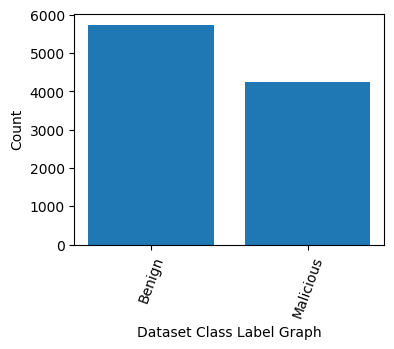

In [5]:
#visualizing Sub Attack class labels count found in dataset
names, count = np.unique(dataset['label'], return_counts = True)
labels = ['Benign', 'Malicious']
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.figure(figsize = (4, 3)) 
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Dataset Class Label Graph")
plt.ylabel("Count")
plt.xticks(rotation=70)
plt.show()

In [6]:
#applying 'Maximal Information Coefficient' algorithm to select features from dataset which is having high scores
#features with high score will help algorithm in getting better acccuracy
Y = dataset['label'].ravel()
dataset.drop(['index', 'label'], axis = 1,inplace=True)
columns = dataset.columns
X = dataset.values
print("Total Features Found in Dataset before applying MINE Features Selection Algorithm = "+str(X.shape[1]))
if os.path.exists("model/fs.npy"):
    top_features = np.load("model/fs.npy")
else:
    mic_scores = []
    mine = MINE()
    for i in range(0, len(columns)-1):#loop and compute mic score for each features
        mine.compute_score(X[:,i], Y)
        mic_scores.append((columns[i], mine.mic()))
    # Sort features by MIC score
    mic_scores.sort(key=lambda x: x[1], reverse=True)
    # Select top features
    top_features = [feature for feature, _ in mic_scores[:35]]  # Select top 2 features
    top_features = np.asarray(top_features)
    np.save("model/fs", top_features)
X = dataset[top_features]
X = X.values    
print("Total Features Found in Dataset after applying MINE Features Selection Algorithm = "+str(X.shape[1]))
print()
print("Selected Features Names = "+str(top_features))

Total Features Found in Dataset before applying MINE Features Selection Algorithm = 75
Total Features Found in Dataset after applying MINE Features Selection Algorithm = 35

Selected Features Names = ['Hour' 'Minute' 'Src_Port' 'Date' 'Dst_Port' 'Month' 'Init_Bwd_Win_Byts'
 'Flow_Duration' 'Flow_Pkts/s' 'TotLen_Bwd_Pkts' 'Flow_IAT_Max' 'Dst_3'
 'Idle_Max' 'Flow_IAT_Mean' 'Idle_Mean' 'Bwd_Pkts/s' 'TotLen_Fwd_Pkts'
 'Pkt_Size_Avg' 'Fwd_Pkt_Len_Mean' 'Fwd_Pkt_Len_Max' 'Fwd_Pkt_Len_Min'
 'Pkt_Len_Mean' 'Bwd_Pkt_Len_Mean' 'Bwd_Pkt_Len_Min' 'Bwd_Header_Len'
 'Pkt_Len_Max' 'Bwd_Pkt_Len_Max' 'Pkt_Len_Min' 'Idle_Min' 'Flow_IAT_Min'
 'ACK_Flag_Cnt' 'Fwd_Pkts/s' 'Flow_Byts/s' 'Fwd_Header_Len' 'Src_3']


In [7]:
#applying MINMAX scaling algorithm to normalize dataset selected features
scaler = MinMaxScaler((0, 1))
X = scaler.fit_transform(X)
print("Normalized Features = "+str(X))

Normalized Features = [[0.3        0.94915254 0.13923406 ... 0.11539714 0.03478261 0.05098039]
 [0.2        0.91525424 0.13923406 ... 0.09293729 0.03478261 0.05098039]
 [0.9        0.10169492 0.10811478 ... 0.         0.10869565 0.84705882]
 ...
 [0.3        0.96610169 0.13923406 ... 0.13790246 0.10434783 0.05098039]
 [0.2        0.3559322  0.00683821 ... 0.37032278 0.03478261 0.84313725]
 [0.         0.83050847 0.00123489 ... 0.28707005 0.04347826 0.25098039]]


In [8]:
#applying PCA dimension reduction algorithm to reduce dimension by removing irrelevant features
print("Total Features Found in Dataset before applying PCA = "+str(X.shape[1]))
pca = PCA(n_components=30)
X = pca.fit_transform(X)
print("Total Features Found in Dataset after applying PCA = "+str(X.shape[1]))

Total Features Found in Dataset before applying PCA = 35
Total Features Found in Dataset after applying PCA = 30


In [ ]:
#shufling and splitting dataset into train and test
indices = np.arange(X.shape[0])

#shuffling dataset
np.random.shuffle(indices)
X = X[indices]
Y = Y[indices]

# Split dataset: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

# Print dataset split details
print("Dataset Train & Test Split Details")
print("80% Text data used to train algorithms : "+str(X_train.shape[0]))
print("20% Text data used to train algorithms : "+str(X_test.shape[0]))


Dataset Train & Test Split Details
80% Text data used to train algorithms : 8000
20% Text data used to train algorithms : 2000
